<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [2]:
!pip install pandas
!pip install seaborn

In [3]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [4]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2025-06-25 14:38:06--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  48.9MB/s    in 3.1s    

2025-06-25 14:38:09 (48.9 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Step 2: Import necessary libraries and load the dataset


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [6]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [7]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



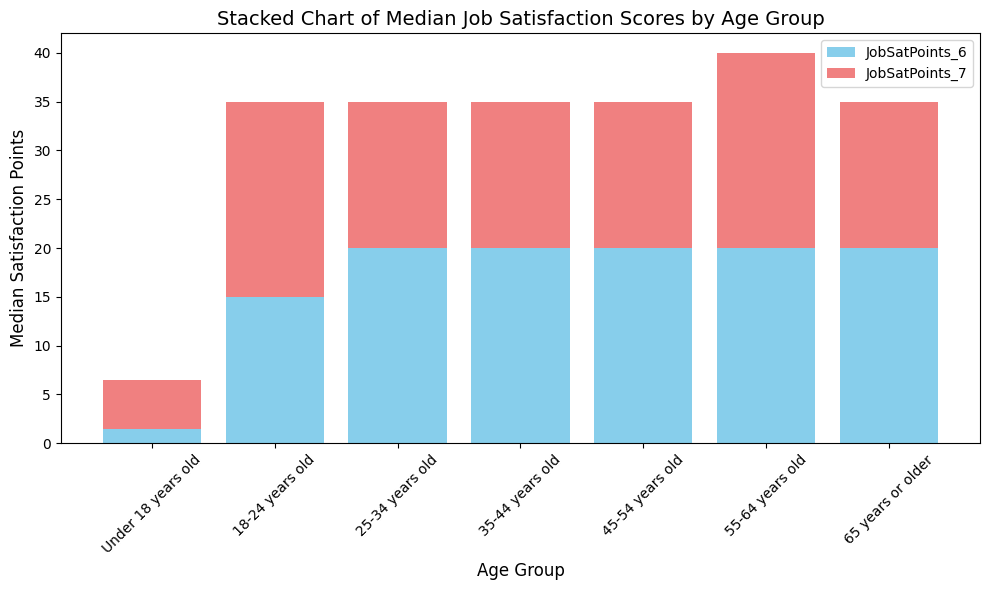

In [8]:
##Write your code here

# Filter necessary columns and drop missing values
df_age_satisfaction = df[['Age', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()

# Map age groups to a consistent order
age_order = [
    'Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old',
    '45-54 years old', '55-64 years old', '65 years or older'
]
df_age_satisfaction = df_age_satisfaction[df_age_satisfaction['Age'].isin(age_order)]

# Group by Age and calculate median satisfaction points
median_satisfaction = df_age_satisfaction.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median().loc[age_order]

# Plot stacked bar chart
plt.figure(figsize=(10, 6))
plt.bar(median_satisfaction.index, median_satisfaction['JobSatPoints_6'], label='JobSatPoints_6', color='skyblue')
plt.bar(median_satisfaction.index, median_satisfaction['JobSatPoints_7'], bottom=median_satisfaction['JobSatPoints_6'], label='JobSatPoints_7', color='lightcoral')

plt.title('Stacked Chart of Median Job Satisfaction Scores by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Satisfaction Points', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


/tmp/ipykernel_908/3529689458.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


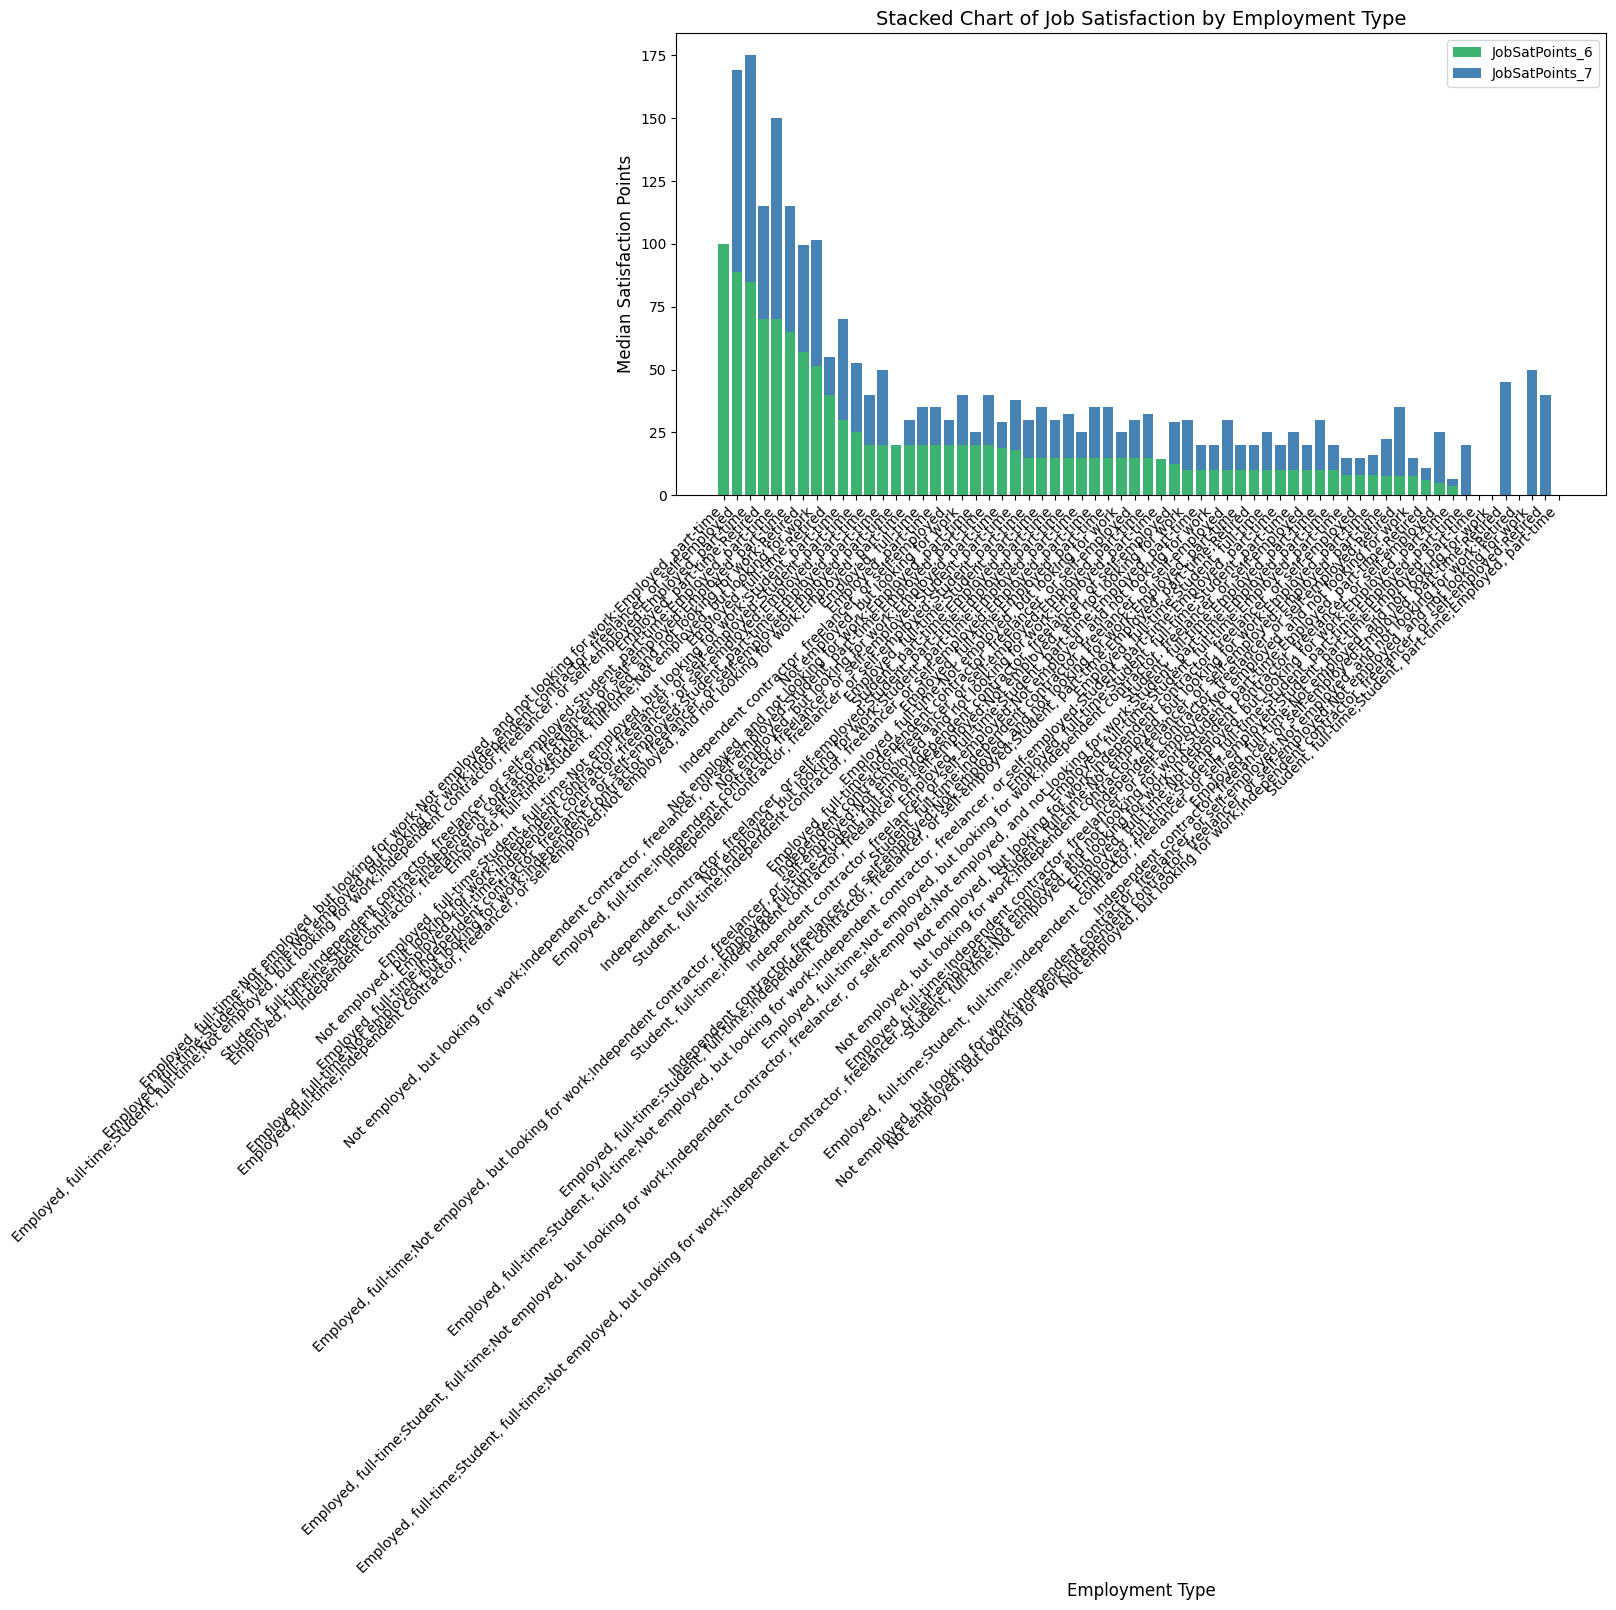

In [9]:
##Write your code here

# Filter necessary columns and drop missing values
df_employment_satisfaction = df[['Employment', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()

# Group by Employment and calculate median satisfaction scores
median_satisfaction_emp = df_employment_satisfaction.groupby('Employment')[['JobSatPoints_6', 'JobSatPoints_7']].median()

# Sort by JobSatPoints_6 for consistent ordering
median_satisfaction_emp = median_satisfaction_emp.sort_values('JobSatPoints_6', ascending=False)

# Plot stacked bar chart
plt.figure(figsize=(12, 6))
plt.bar(median_satisfaction_emp.index, median_satisfaction_emp['JobSatPoints_6'], label='JobSatPoints_6', color='mediumseagreen')
plt.bar(median_satisfaction_emp.index, median_satisfaction_emp['JobSatPoints_7'],
        bottom=median_satisfaction_emp['JobSatPoints_6'], label='JobSatPoints_7', color='steelblue')

plt.title('Stacked Chart of Job Satisfaction by Employment Type', fontsize=14)
plt.xlabel('Employment Type', fontsize=12)
plt.ylabel('Median Satisfaction Points', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


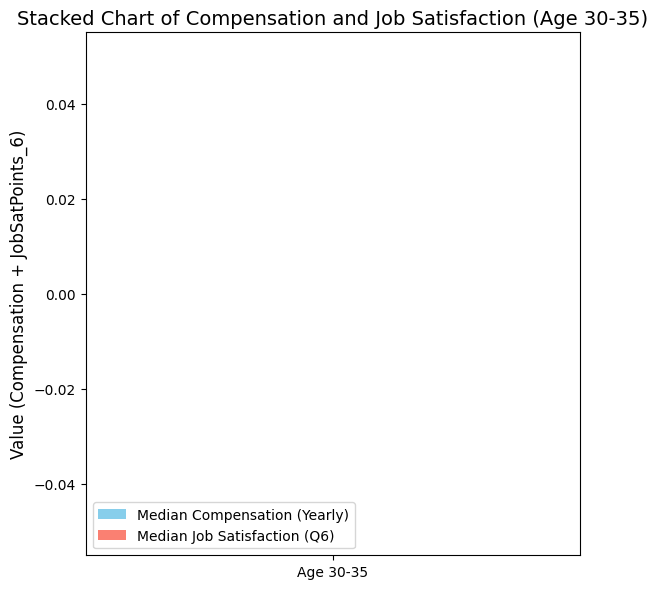

In [10]:
##Write your code here

# Filter relevant columns and drop missing values
df_comp_sat = df[['Age', 'ConvertedCompYearly', 'JobSatPoints_6']].dropna()

# Define a function to approximate numeric age from age group strings
def extract_mid_age(age_str):
    if 'Under' in age_str:
        return 17
    elif '18-24' in age_str:
        return 21
    elif '25-34' in age_str:
        return 29
    elif '35-44' in age_str:
        return 39
    elif '45-54' in age_str:
        return 49
    elif '55-64' in age_str:
        return 59
    elif '65' in age_str:
        return 67
    else:
        return None

# Convert age group to approximate numeric age
df_comp_sat['ApproxAge'] = df_comp_sat['Age'].apply(extract_mid_age)

# Filter for respondents aged approximately between 30 and 35
df_30_35 = df_comp_sat[(df_comp_sat['ApproxAge'] >= 30) & (df_comp_sat['ApproxAge'] <= 35)]

# Calculate median compensation and job satisfaction
comp_median = df_30_35['ConvertedCompYearly'].median()
sat_median = df_30_35['JobSatPoints_6'].median()

# Create a stacked bar chart
plt.figure(figsize=(6, 6))
plt.bar('Age 30-35', comp_median, label='Median Compensation (Yearly)', color='skyblue')
plt.bar('Age 30-35', sat_median, bottom=comp_median, label='Median Job Satisfaction (Q6)', color='salmon')

plt.title('Stacked Chart of Compensation and Job Satisfaction (Age 30-35)', fontsize=14)
plt.ylabel('Value (Compensation + JobSatPoints_6)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


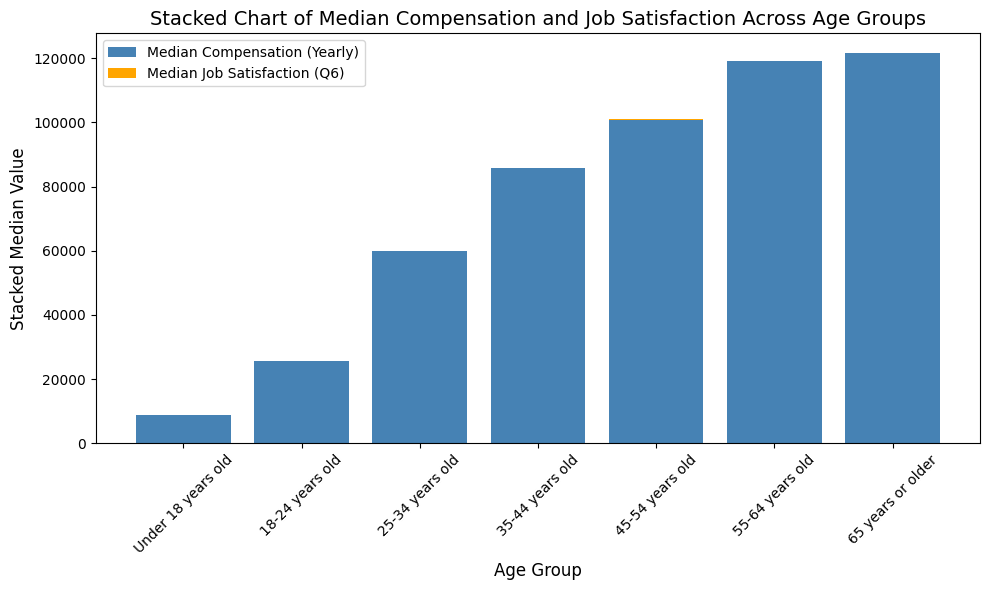

In [11]:
##Write your code here

# Filter relevant columns and drop missing values
df_age_comp_sat = df[['Age', 'ConvertedCompYearly', 'JobSatPoints_6']].dropna()

# Define age group order for consistent plotting
age_order = [
    'Under 18 years old', '18-24 years old', '25-34 years old',
    '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older'
]

# Keep only rows with valid age groups
df_age_comp_sat = df_age_comp_sat[df_age_comp_sat['Age'].isin(age_order)]

# Group by Age and calculate median compensation and satisfaction
median_values = df_age_comp_sat.groupby('Age')[['ConvertedCompYearly', 'JobSatPoints_6']].median().loc[age_order]

# Plot stacked bar chart
plt.figure(figsize=(10, 6))
plt.bar(median_values.index, median_values['ConvertedCompYearly'], label='Median Compensation (Yearly)', color='steelblue')
plt.bar(median_values.index, median_values['JobSatPoints_6'],
        bottom=median_values['ConvertedCompYearly'], label='Median Job Satisfaction (Q6)', color='orange')

plt.title('Stacked Chart of Median Compensation and Job Satisfaction Across Age Groups', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Stacked Median Value', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


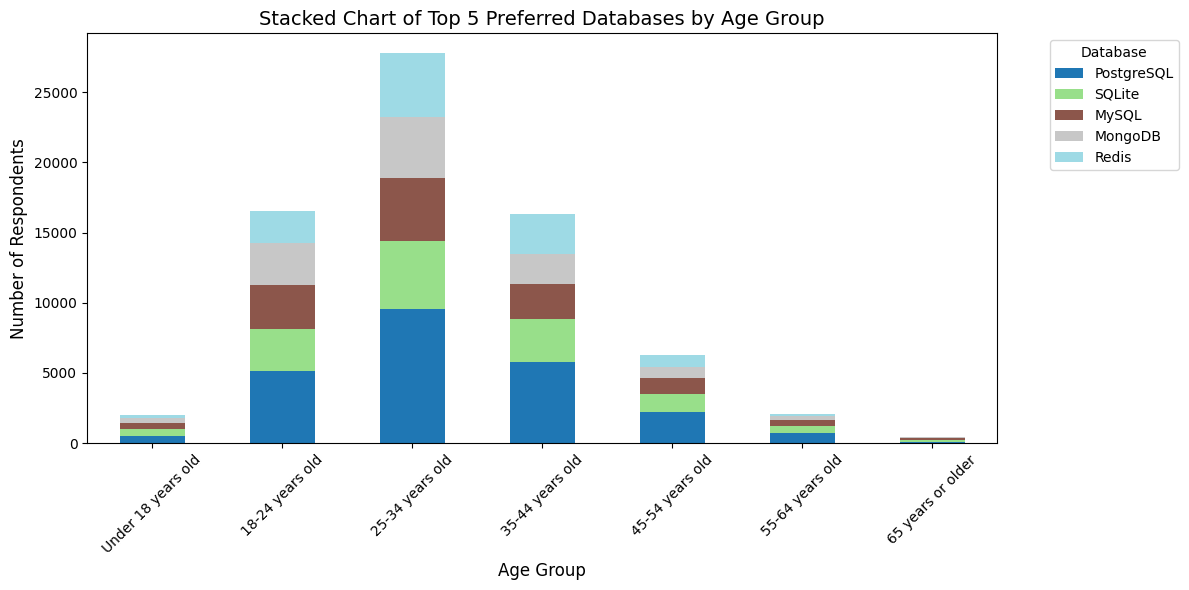

In [12]:
##Write your code here

# Filter relevant columns and drop missing values
df_db_age = df[['Age', 'DatabaseWantToWorkWith']].dropna()

# Define age group order
age_order = [
    'Under 18 years old', '18-24 years old', '25-34 years old',
    '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older'
]

# Filter for known age groups
df_db_age = df_db_age[df_db_age['Age'].isin(age_order)]

# Split multiple databases and explode into rows
df_db_age['DatabaseWantToWorkWith'] = df_db_age['DatabaseWantToWorkWith'].str.split(';')
df_db_age = df_db_age.explode('DatabaseWantToWorkWith')

# Count databases per age group
db_counts = df_db_age.groupby(['Age', 'DatabaseWantToWorkWith']).size().unstack(fill_value=0)

# Keep top 5 databases across all age groups
top_databases = df_db_age['DatabaseWantToWorkWith'].value_counts().head(5).index
db_counts = db_counts[top_databases]

# Reorder index by age_order
db_counts = db_counts.reindex(age_order)

# Plot stacked bar chart
db_counts.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')

plt.title('Stacked Chart of Top 5 Preferred Databases by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Database', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


/tmp/ipykernel_908/3977851843.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


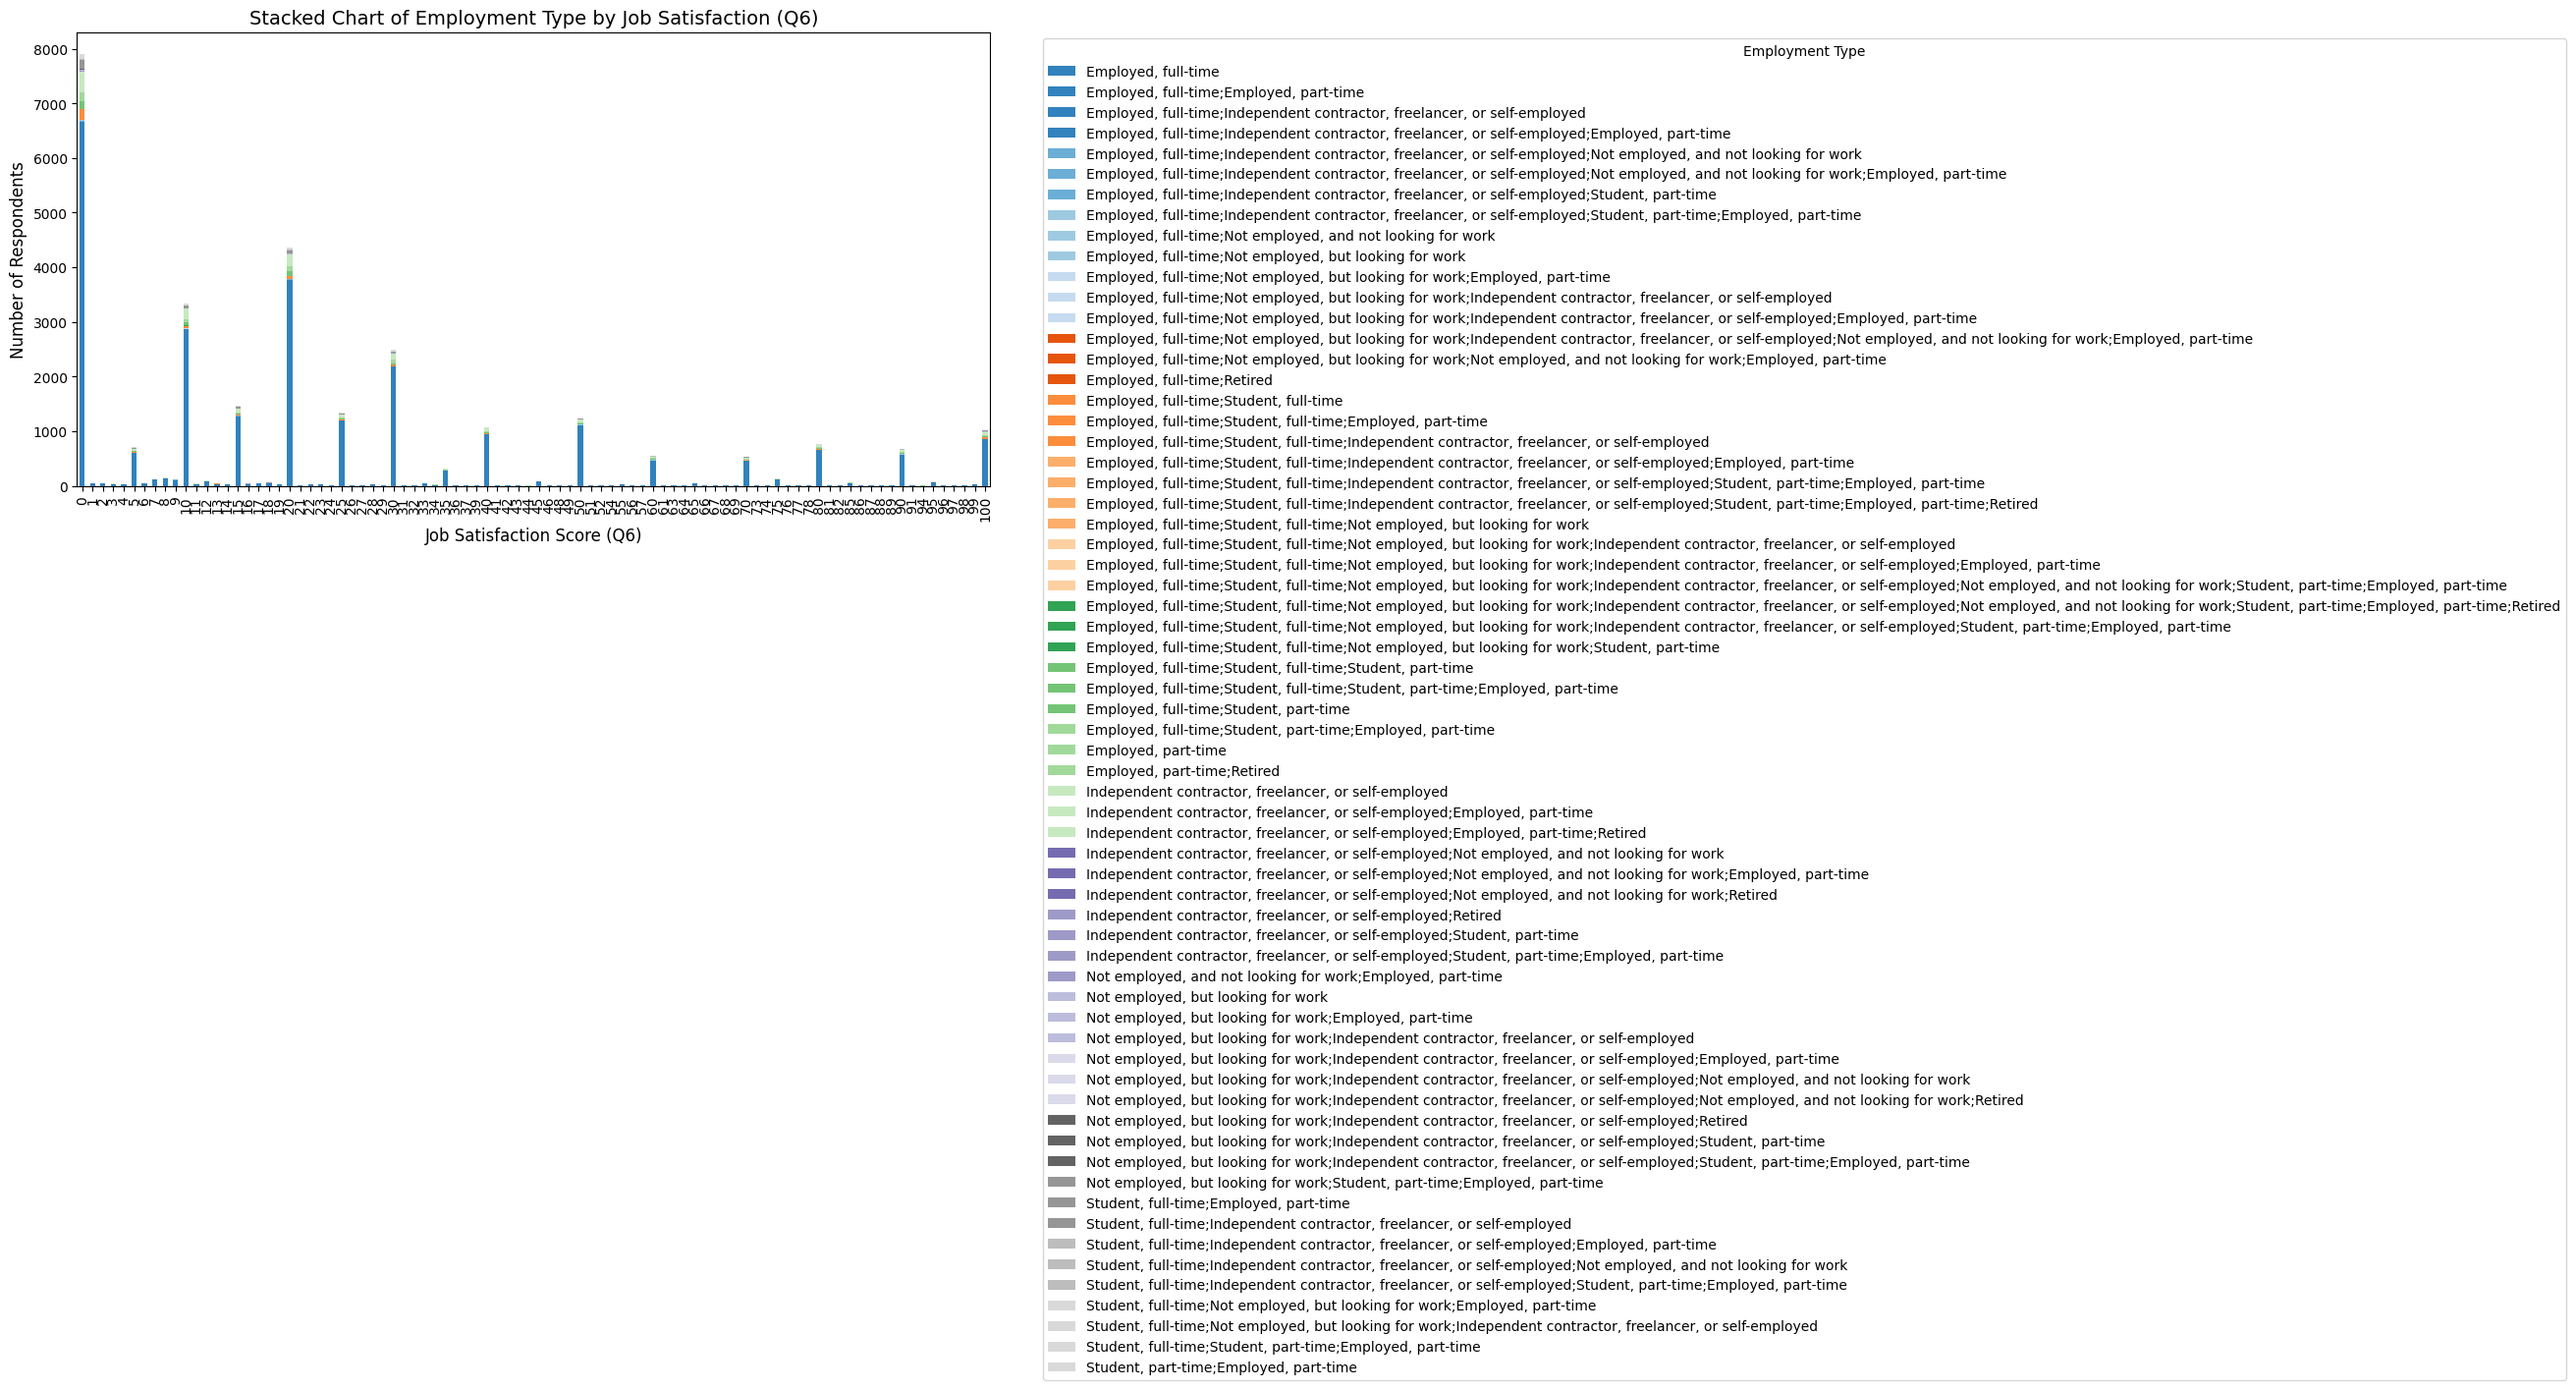

In [13]:
##Write your code here

# Filter relevant columns and drop missing values
df_emp_sat = df[['Employment', 'JobSatPoints_6']].dropna()

# Convert JobSatPoints_6 to integer if not already
df_emp_sat['JobSatPoints_6'] = df_emp_sat['JobSatPoints_6'].astype(int)

# Create a cross-tabulation of JobSatPoints_6 by Employment
emp_sat_ct = pd.crosstab(df_emp_sat['JobSatPoints_6'], df_emp_sat['Employment'])

# Sort index to show satisfaction scores in order
emp_sat_ct = emp_sat_ct.sort_index()

# Plot stacked bar chart
emp_sat_ct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20c')

plt.title('Stacked Chart of Employment Type by Job Satisfaction (Q6)', fontsize=14)
plt.xlabel('Job Satisfaction Score (Q6)', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


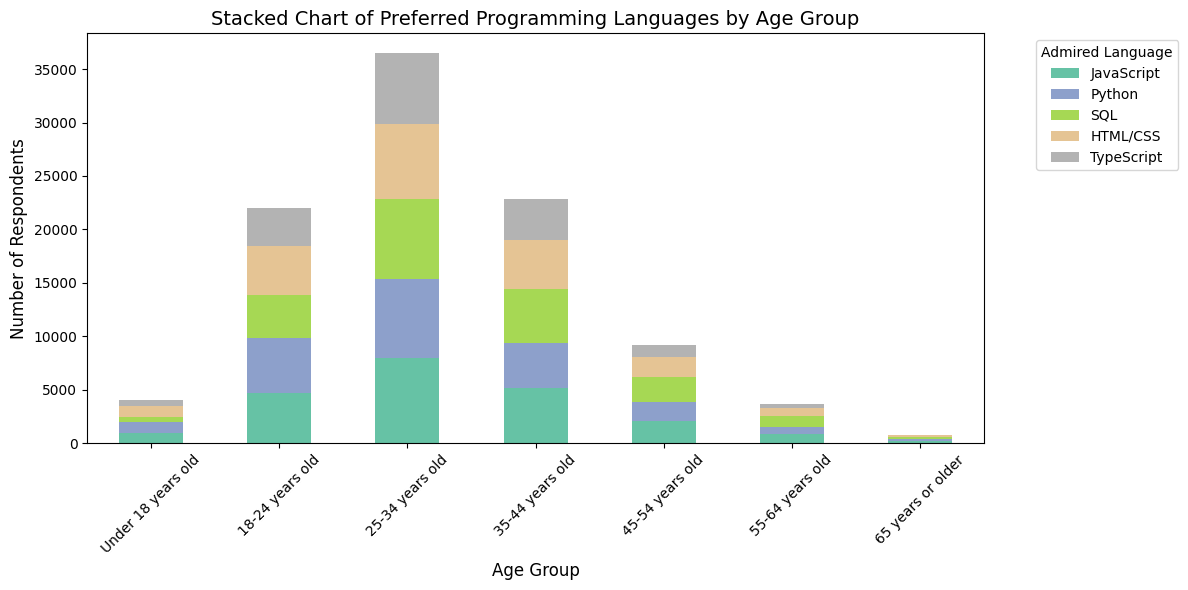

In [14]:
##Write your code here

# Filter necessary columns and drop missing values
df_lang_age = df[['Age', 'LanguageAdmired']].dropna()

# Define age group order
age_order = [
    'Under 18 years old', '18-24 years old', '25-34 years old',
    '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older'
]

# Filter valid age groups only
df_lang_age = df_lang_age[df_lang_age['Age'].isin(age_order)]

# Split multiple languages and explode into separate rows
df_lang_age['LanguageAdmired'] = df_lang_age['LanguageAdmired'].str.split(';')
df_lang_age = df_lang_age.explode('LanguageAdmired')

# Count occurrences of each language per age group
lang_counts = df_lang_age.groupby(['Age', 'LanguageAdmired']).size().unstack(fill_value=0)

# Keep top 5 most admired languages overall
top_languages = df_lang_age['LanguageAdmired'].value_counts().head(5).index
lang_counts = lang_counts[top_languages]

# Reorder age groups
lang_counts = lang_counts.reindex(age_order)

# Plot stacked bar chart
lang_counts.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')

plt.title('Stacked Chart of Preferred Programming Languages by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Admired Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


/tmp/ipykernel_908/1502720865.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


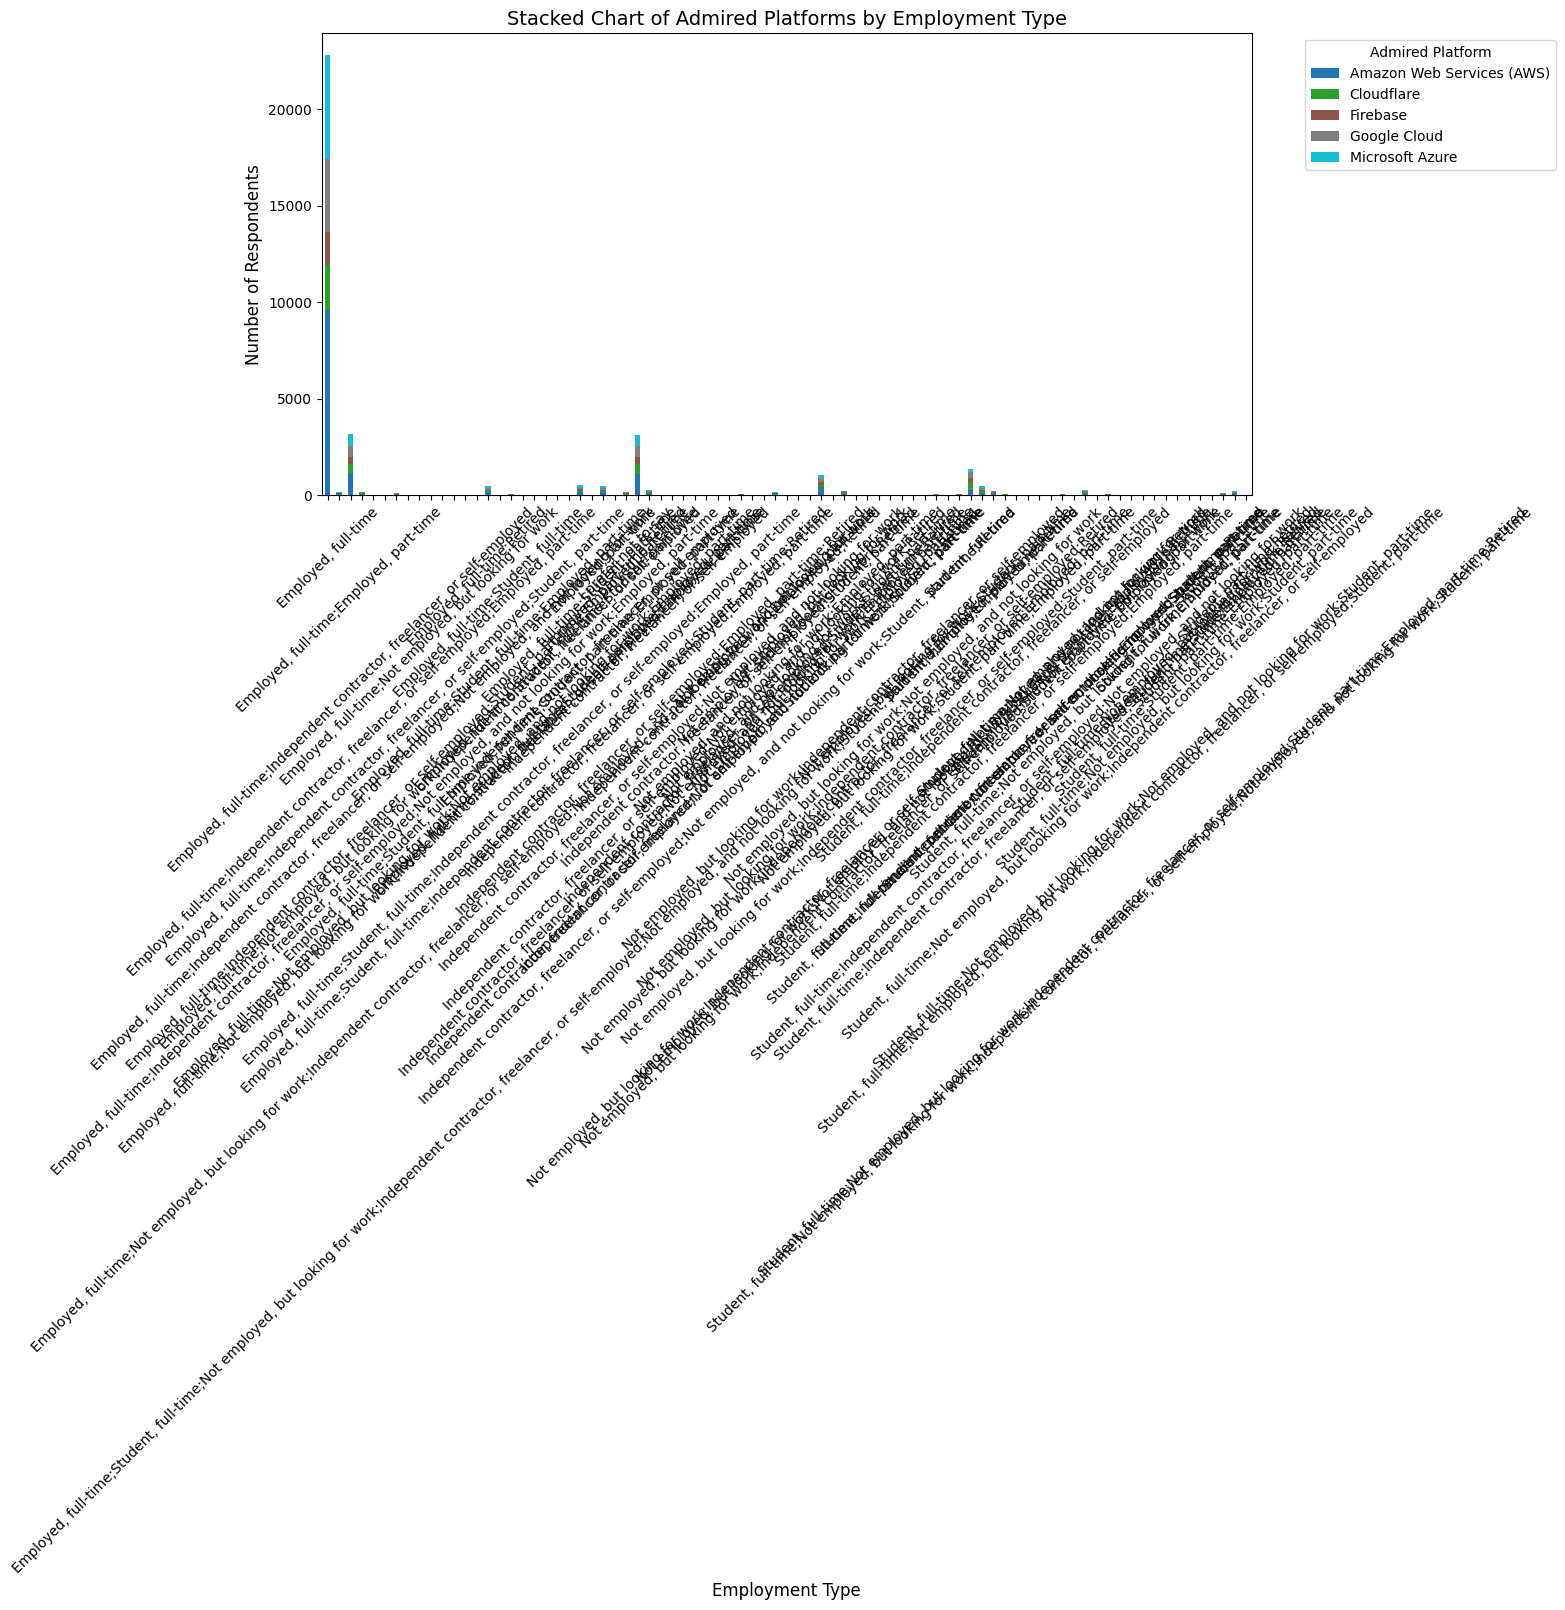

In [15]:
##Write your code here

# Filter relevant columns and drop missing values
df_tech_emp = df[['Employment', 'PlatformAdmired']].dropna()

# Split multiple platforms into separate rows
df_tech_emp['PlatformAdmired'] = df_tech_emp['PlatformAdmired'].str.split(';')
df_tech_emp = df_tech_emp.explode('PlatformAdmired')

# Get top 5 admired platforms overall
top_platforms = df_tech_emp['PlatformAdmired'].value_counts().head(5).index

# Filter only top platforms
df_tech_emp = df_tech_emp[df_tech_emp['PlatformAdmired'].isin(top_platforms)]

# Count platform admiration by employment type
platform_counts = df_tech_emp.groupby(['Employment', 'PlatformAdmired']).size().unstack(fill_value=0)

# Plot stacked bar chart
platform_counts.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')

plt.title('Stacked Chart of Admired Platforms by Employment Type', fontsize=14)
plt.xlabel('Employment Type', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Admired Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
